In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.layers import Dropout
from keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Alexandra model/Forecasting_set/3.csv')
df = df.rename(columns={"energy": "VAL"})


In [ ]:
df.head()

,DateTime,year,month_of_yr,day_of_yr,day_of_month,day_of_week,weekend,holiday,hour,season,VAL
0,2007-03-09,2007,3,68,9,4,0,0,1,2,216540.0
1,2007-03-09,2007,3,68,9,4,0,0,2,2,217565.0
2,2007-03-09,2007,3,68,9,4,0,0,3,2,220467.0
3,2007-03-09,2007,3,68,9,4,0,0,4,2,222781.0
4,2007-03-09,2007,3,68,9,4,0,0,5,2,232742.0


In [ ]:
df.drop(columns=['DateTime'], inplace = True)

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df.drop('hour', axis=1, inplace=True)  # Drop the original hour column

df['month_sin'] = np.sin(2 * np.pi * df['month_of_yr']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_yr']/12)
df['day_month_sin'] = np.sin(2 * np.pi * df['day_of_month']/31)
df['day_month_cos'] = np.cos(2 * np.pi * df['day_of_month']/31)
df.drop(['month_of_yr', 'day_of_month'], axis=1, inplace=True)

df['day_year_sin'] = np.sin(2 * np.pi * df['day_of_yr']/365)
df['day_year_cos'] = np.cos(2 * np.pi * df['day_of_yr']/365)
df.drop('day_of_yr', axis=1, inplace=True)

# Assuming 'season' has values from 1 to 4
df['season_sin'] = np.sin(2 * np.pi * df['season']/4)
df['season_cos'] = np.cos(2 * np.pi * df['season']/4)

# Optionally, drop the original 'season' column if it will no longer be used
df.drop('season', axis=1, inplace=True)

# Assuming 'day_of_week' is 0 for Sunday, 1 for Monday, ..., 6 for Saturday
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Optionally, drop the original 'day_of_week' column if it will no longer be used
df.drop('day_of_week', axis=1, inplace=True)


scaler = MinMaxScaler()
df[['year']] = scaler.fit_transform(df[['year']])

df.drop('year', axis=1, inplace=True)
df.drop('weekend', axis=1, inplace=True) # weekend might be redundant if day_of_week_sin and day_of_week_cos adequately encode the difference between weekends and weekdays.
df.drop('day_year_sin', axis=1, inplace=True)
df.drop('day_year_cos', axis=1, inplace=True) #There might be some overlap with month_sin, month_cos, season_sin, and season_cos as they all aim to capture time-based patterns throughout the year.
df.drop('season_sin', axis=1, inplace=True)
df.drop('season_cos', axis=1, inplace=True) #hese features are similar to month_sin and month_cos but are broader, capturing larger seasonal patterns.


In [ ]:
df.head()

,holiday,VAL,hour_sin,hour_cos,month_sin,month_cos,day_month_sin,day_month_cos,day_of_week_sin,day_of_week_cos
0,0,216540.0,0.258819,0.965926,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
1,0,217565.0,0.500000,0.866025,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
2,0,220467.0,0.707107,0.707107,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
3,0,222781.0,0.866025,0.500000,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
4,0,232742.0,0.965926,0.258819,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969


In [ ]:
target = df['VAL']
# features = df.drop(columns=['VAL'], axis = 1)
# features = df['VAL']
# save_features = df['VAL']
features = df
save_features = df
# save_target = df['VAL']

In [ ]:
print(features.columns)


Index(['holiday', 'VAL', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'day_month_sin', 'day_month_cos', 'day_of_week_sin', 'day_of_week_cos'],
      dtype='object')


In [ ]:
# Initialize the scaler for the features
feature_scaler = MinMaxScaler()

# # Scale the features
# # features = feature_scaler.fit_transform(features)
# features = feature_scaler.fit_transform(features.values.reshape(-1, 1))

# # Initialize a separate scaler for the target since it has a different number of features
# target_scaler = MinMaxScaler()

# # Scale the target
# target = target_scaler.fit_transform(target.values.reshape(-1, 1))

# # Convert the scaled target back to a 1D array
# target = target.flatten()

features['VAL'] = feature_scaler.fit_transform(features['VAL'].values.reshape(-1, 1))

# Initialize a separate scaler for the target since it has a different number of features
target_scaler = MinMaxScaler()

# Scale the target
target = target_scaler.fit_transform(target.values.reshape(-1, 1))

# Convert the scaled target back to a 1D array
target = target.flatten()

In [ ]:
features.columns

Index(['holiday', 'VAL', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'day_month_sin', 'day_month_cos', 'day_of_week_sin', 'day_of_week_cos'],
      dtype='object')

In [ ]:
features = pd.DataFrame(features, columns=save_features.columns)
# features = pd.DataFrame(target, columns=['VAL'])
# Convert scaled target back to Series
target = pd.DataFrame(target, columns=['VAL'])

In [ ]:
# target.head()
features.head()

,holiday,VAL,hour_sin,hour_cos,month_sin,month_cos,day_month_sin,day_month_cos,day_of_week_sin,day_of_week_cos
0,0,0.493043,0.258819,0.965926,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
1,0,0.497675,0.500000,0.866025,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
2,0,0.510790,0.707107,0.707107,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
3,0,0.521247,0.866025,0.500000,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969
4,0,0.566263,0.965926,0.258819,1.0,6.123234e-17,0.968077,-0.250653,-0.433884,-0.900969


In [ ]:
# features.drop(columns= ['year', 'day_of_yr', 'season'])

In [ ]:
# Calculate test size and validation size
test_size = int(len(df) * 0.1)
val_size = int(len(df) * 0.1)

# Split the data manually to preserve the time series sequence
X_train = features.iloc[:-(test_size + val_size), :]
y_train = target.iloc[:-(test_size + val_size), :]

X_val = features.iloc[-(test_size + val_size):-test_size, :]
y_val = target.iloc[-(test_size + val_size):-test_size, :]

X_test = features.iloc[-test_size:, :]
y_test = target.iloc[-test_size:, :]


In [ ]:
# Define the sequence length for input and output
input_seq_length = 48
output_seq_length = 24

# Function to prepare the data
def prepare_data(features, targets, input_seq_length, output_seq_length):
    X, y = [], []
    for i in range(len(features) - input_seq_length - output_seq_length):
        X.append(features[i:i+input_seq_length])
        y.append(targets[i+input_seq_length:i+input_seq_length+output_seq_length])
    return np.array(X), np.array(y)

# Prepare the data
X_train, y_train = prepare_data(X_train.values, y_train.values, input_seq_length, output_seq_length)
X_val, y_val = prepare_data(X_val.values, y_val.values, input_seq_length, output_seq_length)
X_test, y_test = prepare_data(X_test.values, y_test.values, input_seq_length, output_seq_length)


In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


X_train shape: (9280, 48, 10)
X_val shape: (1096, 48, 10)
X_test shape: (1096, 48, 10)


In [ ]:
# Define the LSTM model

model = Sequential()
# Assuming input_shape=(input_seq_length, num_features), adjust 'num_features' as per your dataset
model.add(LSTM(50, input_shape=(input_seq_length, 10), return_sequences=False))
model.add(Dropout(0.2))  # Adds dropout with a 20% rate of dropping out input units, helps prevent overfitting
# Dense layer to output the predicted sequence
# If you predict multiple steps at once, ensure the output dimension matches the number of steps
model.add(Dense(output_seq_length))
model.compile(optimizer='adam', loss='mse')

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_data=(X_val, y_val), verbose=1, callbacks=[early_stopping])

# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
val_loss = model.evaluate(X_val, y_val, verbose=0)
test_loss = model.evaluate(X_test, y_test, verbose=0)

print("Train Loss:", train_loss)
print("Validation Loss:", val_loss)
print("Test Loss:", test_loss)


Epoch 1/500
290/290 [==============================] - 9s 26ms/step - loss: 0.0371 - val_loss: 0.0053
Epoch 2/500
290/290 [==============================] - 5s 18ms/step - loss: 0.0127 - val_loss: 0.0045
Epoch 3/500
290/290 [==============================] - 7s 24ms/step - loss: 0.0102 - val_loss: 0.0052
Epoch 4/500
290/290 [==============================] - 5s 18ms/step - loss: 0.0090 - val_loss: 0.0034
Epoch 5/500
290/290 [==============================] - 6s 19ms/step - loss: 0.0081 - val_loss: 0.0038
Epoch 6/500
290/290 [==============================] - 7s 23ms/step - loss: 0.0073 - val_loss: 0.0023
Epoch 7/500
290/290 [==============================] - 5s 18ms/step - loss: 0.0067 - val_loss: 0.0024
Epoch 8/500
290/290 [==============================] - 7s 24ms/step - loss: 0.0060 - val_loss: 0.0029
Epoch 9/500
290/290 [==============================] - 5s 18ms/step - loss: 0.0057 - val_loss: 0.0025
Epoch 10/500
290/290 [==============================] - 8s 28ms/step - loss: 0.005

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

y_pred=y_pred[:, 0]
y_test = y_test[:, 0]

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  # Create a mask to identify non-zero values in y_true
    if np.any(mask):  # Check if there are any non-zero values
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        return mape
    else:
        return 0  # Return 0 if all y_true values are zero, which prevents division by zero


y_test_flat = y_test.reshape(y_pred.shape)

# Calculate MAPE
mape = mean_absolute_percentage_error(y_test_flat, y_pred)
print("Mean Absolute Percentage Error (MAPE):", mape)

35/35 [==============================] - 1s 19ms/step
Mean Absolute Percentage Error (MAPE): 10.928824817893721


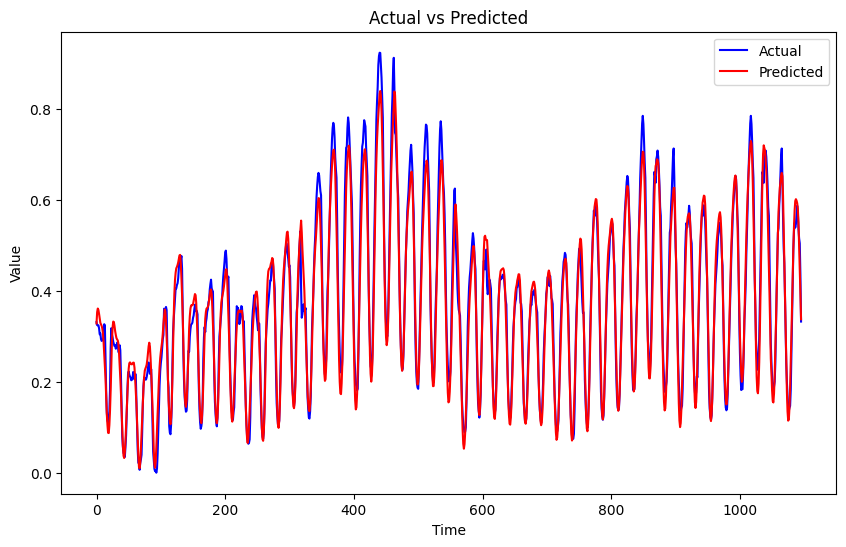

In [ ]:
import matplotlib.pyplot as plt

# Define the time index for plotting
time_index = range(len(y_test))

# Plot y_test and y_pred
plt.figure(figsize=(10, 6))
plt.plot(time_index, y_test_flat, label='Actual', color='blue')
plt.plot(time_index, y_pred, label='Predicted', color='red')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

Mean Absolute Percentage Error (MAPE) for first 100 steps: 36.860527143710634


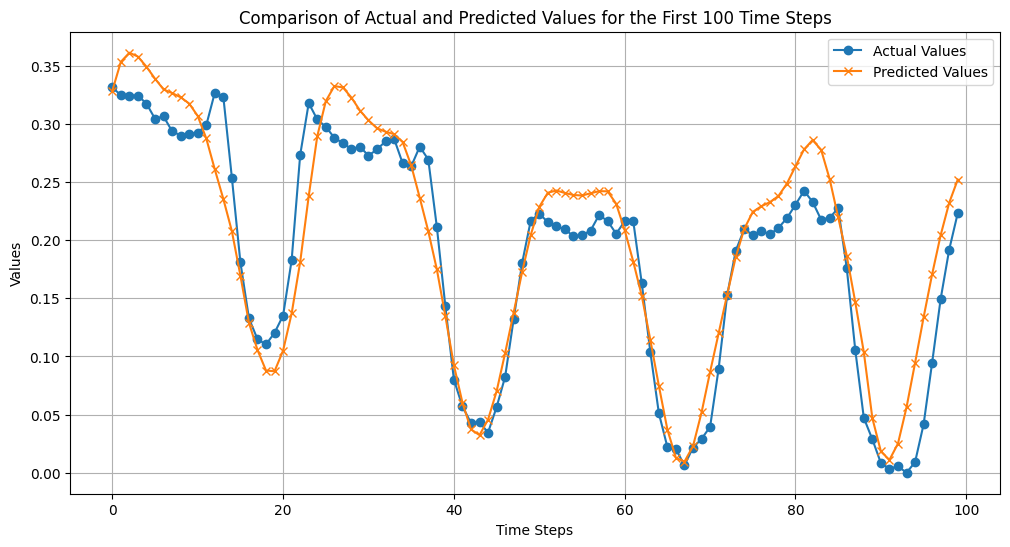

In [ ]:
# Assuming y_pred and y_test_flat are numpy arrays and already compatible in shape
# Slice the first 100 elements for visualization
y_pred_100 = y_pred[:100]
y_test_flat_100 = y_test_flat[:100]

# Calculate MAPE for the first 100 steps
mape_100 = mean_absolute_percentage_error(y_test_flat_100, y_pred_100)
print("Mean Absolute Percentage Error (MAPE) for first 100 steps:", mape_100)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(y_test_flat_100, label='Actual Values', marker='o')
plt.plot(y_pred_100, label='Predicted Values', marker='x')
plt.title('Comparison of Actual and Predicted Values for the First 100 Time Steps')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred

array([[0.3954674 , 0.41960335, 0.40782464, ..., 0.31419146, 0.27730247,
        0.33750623],
       [0.40436694, 0.42206922, 0.4073183 , ..., 0.33054176, 0.2932298 ,
        0.3498252 ],
       [0.4091745 , 0.42184874, 0.4046207 , ..., 0.34402636, 0.3070518 ,
        0.35945392],
       ...,
       [0.1940364 , 0.20991138, 0.15844905, ..., 0.28921443, 0.312373  ,
        0.29724216],
       [0.18853596, 0.2013998 , 0.14927852, ..., 0.28832793, 0.31241408,
        0.29072493],
       [0.18318918, 0.19299996, 0.14047417, ..., 0.2877657 , 0.31230792,
        0.2843709 ]], dtype=float32)

In [ ]:
y_test

array([[[0.33126054],
        [0.32466253],
        [0.32421061],
        ...,
        [0.18275119],
        [0.27321165],
        [0.31786116]],

       [[0.32466253],
        [0.32421061],
        [0.32434167],
        ...,
        [0.27321165],
        [0.31786116],
        [0.30375228]],

       [[0.32421061],
        [0.32434167],
        [0.31736405],
        ...,
        [0.31786116],
        [0.30375228],
        [0.29742542]],

       ...,

       [[0.50447173],
        [0.4347046 ],
        [0.33249427],
        ...,
        [0.55235246],
        [0.50691209],
        [0.46082547]],

       [[0.4347046 ],
        [0.33249427],
        [0.25800008],
        ...,
        [0.50691209],
        [0.46082547],
        [0.42727507]],

       [[0.33249427],
        [0.25800008],
        [0.2027802 ],
        ...,
        [0.46082547],
        [0.42727507],
        [0.34079149]]])